In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Multi-Agent Data Analyst

## 0. Library Installation

In [ ]:
!pip install -q -U google-genai
!pip install -q -U langchain langchain-core langchain-classic
!pip install -q pandas numpy scipy matplotlib seaborn openpyxl
!pip install -q excel-parser

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.0/260.0 kB 18.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.57.1 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.5/161.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.7/571.7 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 24.8 MB/s eta 0:00:00
ERROR: Could not find a version that satisfies the requirement excel-parser (from versions: none)
ERROR: No matching distribution found for excel-parser


## 1. Load 5 API Keys from Kaggle/Colab Secrets (SECURE — no hardcoded keys)

In [ ]:
from google.colab import userdata
import os

keys = userdata.get("GOOGLE_API_KEYS")

os.environ["GOOGLE_API_KEYS"] = keys

api_keys = [k.strip() for k in keys.split(",") if k.strip()]

print(f"✅ Đã nạp {len(api_keys)} API keys")

✅ Đã nạp 5 API keys


## 2. Import & Initialize the System

setup() connects to Gemma 4 26B-A4B-IT (with API key rotation enabled), builds specialist agents and 1 orchestrator, and returns the analyze() function.

In [ ]:
import sys, os

PROJECT_DIR = "/content/drive/MyDrive/Ai-Agent-Practice"

assert os.path.exists(os.path.join(PROJECT_DIR, "main.py")), \
    f"Không thấy main.py trong {PROJECT_DIR} — kiểm tra lại đường dẫn"

sys.path.insert(0, PROJECT_DIR)

from main import setup
from data_store import store
from metrics import monitor

analyze = setup()

✅ RotatingGeminiClient sẵn sàng với 5 key, model=gemma-4-26b-a4b-it
✅ 5 specialist agents đã sẵn sàng
✅ Master orchestrator sẵn sàng - gọi analyze('câu hỏi') để dùng


## 3. Quick Demo — Create a Dataset with CUSTOM COLUMN NAMES

In [ ]:
print(analyze("Tạo dataset tên 'don_hang' với các cột: ID_san_pham (id), ngay_ban (date), gia (float), so_luong_ban (int)"))



> Entering new AgentExecutor chain...
🔄 Rate limit - chuyển sang key #2/5
🔄 Rate limit - chuyển sang key #3/5
🔄 Rate limit - chuyển sang key #4/5
🔄 Rate limit - chuyển sang key #5/5
Tôi cần tạo một bộ dữ liệu mới có tên là 'don_hang' với các cột cụ thể là 'ID_san_pham', 'ngay_ban', 'gia', và 'so_luong_ban' theo yêu cầu của người dùng. Tôi sẽ sử dụng công cụ `data_loader_agent` để thực hiện việc này.

Action: data_loader_agent
Action Input: task=Tạo dataset tên 'don_hang' với các cột ID_san_pham (kiểu id), ngay_ban (kiểu date), gia (kiểu float), so_luong_ban (kiểu int)

> Entering new AgentExecutor chain...
Tôi cần tạo một bộ dữ liệu mới có tên là 'don_hang' với các cột và kiểu dữ liệu cụ thể theo yêu cầu của người dùng. Tôi sẽ sử dụng công cụ `create_custom_dataset` để thực hiện việc này.

Action: create_custom_dataset
Action Input: dataset_name=don_hang, n_rows=100, columns=ID_san_pham:id,ngay_ban:date,gia:float,so_luong_ban:intĐã tạo dataset 'don_hang' với 100 dòng, ĐÚNG cột yêu cầ

In [ ]:
store.debug()

- 'don_hang': 100 dòng x 4 cột -> ['ID_san_pham', 'ngay_ban', 'gia', 'so_luong_ban']


## 4. Load the Actual CSV

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving nykaa_campaign_data.csv to nykaa_campaign_data.csv


In [ ]:
print(analyze("Load file CSV tại /content/nykaa_campaign_data.csv, đặt tên là 'campaign'"))



> Entering new AgentExecutor chain...
Tôi cần sử dụng công cụ `data_loader_agent` để tải tệp CSV từ đường dẫn được cung cấp và đặt tên cho nó là 'campaign'.

Action: data_loader_agent
Action Input: task=Load file CSV tại /content/nykaa_campaign_data.csv và đặt tên là campaign

> Entering new AgentExecutor chain...
Tôi cần sử dụng công cụ `load_csv` để tải tệp tin từ đường dẫn được cung cấp và đặt tên cho tập dữ liệu là `campaign`.

Action: load_csv
Action Input: file_path=/content/nykaa_campaign_data.csv, dataset_name=campaignĐã load 'campaign': 55555 dòng, cột: ['Campaign_ID', 'Campaign_Type', 'Target_Audience', 'Duration', 'Channel_Used', 'Impressions', 'Clicks', 'Leads', 'Conversions', 'Revenue', 'Acquisition_Cost', 'ROI', 'Language', 'Engagement_Score', 'Customer_Segment', 'Date']Tôi đã tải thành công tệp tin CSV tại đường dẫn `/content/nykaa_campaign_data.csv` và đặt tên cho tập dữ liệu là `campaign`. Tập dữ liệu này bao gồm 55.555 dòng với các cột như sau: `Campaign_ID`, `Campa

In [ ]:
store.debug()

- 'don_hang': 100 dòng x 4 cột -> ['ID_san_pham', 'ngay_ban', 'gia', 'so_luong_ban']
- 'campaign': 55555 dòng x 16 cột -> ['Campaign_ID', 'Campaign_Type', 'Target_Audience', 'Duration', 'Channel_Used', 'Impressions', 'Clicks', 'Leads', 'Conversions', 'Revenue', 'Acquisition_Cost', 'ROI', 'Language', 'Engagement_Score', 'Customer_Segment', 'Date']


## 5. Analyze & Visualize the Results



> Entering new AgentExecutor chain...
Thought: Tôi cần mô tả dữ liệu của tập dữ liệu 'don_hang' bằng cách sử dụng chuyên gia thống kê.

Action: statistician_agent
Action Input: task=mô tả tập dữ liệu don_hang

> Entering new AgentExecutor chain...
Tôi cần sử dụng công cụ `describe_dataset` để lấy các thống kê mô tả đầy đủ cho tập dữ liệu có tên là `don_hang`.

Action: describe_dataset
Action Input: dataset_name=don_hang       ID_san_pham             ngay_ban         gia  so_luong_ban
count   100.000000                  100  100.000000     100.00000
mean     50.500000  2024-02-19 12:00:00  475.479300     517.01000
min       1.000000  2024-01-01 00:00:00   15.470000       2.00000
25%      25.750000  2024-01-25 18:00:00  201.267500     309.25000
50%      50.500000  2024-02-19 12:00:00  469.500000     556.50000
75%      75.250000  2024-03-15 06:00:00  732.900000     699.00000
max     100.000000  2024-04-09 00:00:00  987.020000     997.00000
std      29.011492                  NaN  294.51

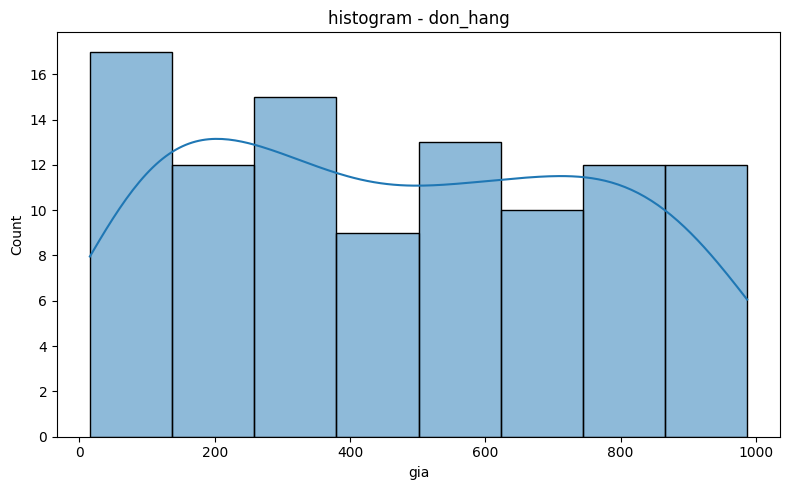

Đã tạo biểu đồ histogram, lưu tại /content/last_chart.png

Insight cho cột 'gia':
- Trung bình=475.48, Trung vị=469.50, Độ lệch chuẩn=294.51, Min=15.47, Max=987.02.
- Phân bố tương đối đối xứng (skewness=0.11).
- Không phát hiện outlier đáng kể (method=IQR).
- Theo 'ngay_ban': không có xu hướng tăng/giảm rõ rệt.Tôi đã có đủ thông tin để trả lời.

Final Answer: Biểu đồ histogram cho cột `gia` của tập dữ liệu `don_hang` đã được tạo thành công và lưu tại `/content/last_chart.png`. Dựa trên các thông số thống kê, giá bán có giá trị trung bình là 475.48, trung vị là 469.50 và dao động trong khoảng từ 15.47 đến 987.02. Phân bố của giá bán tương đối đối xứng với độ lệch thấp (0.11) và không có các giá trị ngoại lệ đáng kể.

> Finished chain.
Biểu đồ histogram cho cột `gia` của tập dữ liệu `don_hang` đã được tạo thành công và lưu tại `/content/last_chart.png`. Dựa trên các thông số thống kê, giá bán có giá trị trung bình là 475.48, trung vị là 469.50 và dao động trong khoảng từ 15.47 đến 987.0

In [ ]:
print(analyze("Describe 'don_hang' và vẽ histogram của gia"))

In [ ]:
print(analyze("Cho tôi nhận xét về cột gia trong don_hang"))



> Entering new AgentExecutor chain...
Tôi cần phân tích thống kê cho cột 'gia' trong tập dữ liệu 'don_hang' để đưa ra các nhận xét và thông tin chi tiết về cột này.

Action: statistician_agent
Action Input: task=nhận xét cột gia của dataset don_hang

> Entering new AgentExecutor chain...
Tôi cần sử dụng công cụ `generate_insights` để đưa ra nhận xét về cột `gia` trong tập dữ liệu `don_hang`.

Action: generate_insights
Action Input: dataset_name=don_hang, column=gia=== INSIGHT cho cột 'gia' (dataset 'don_hang') ===
- Trung bình=475.48, Trung vị=469.50, Độ lệch chuẩn=294.51, Min=15.47, Max=987.02.
- Phân bố tương đối đối xứng (skewness=0.11).
- Không phát hiện outlier đáng kể (method=IQR).
- Theo 'ngay_ban': không có xu hướng tăng/giảm rõ rệt.Tôi đã có đủ thông tin để trả lời.

Final Answer: Dưới đây là các nhận xét về cột `gia` trong tập dữ liệu `don_hang`:
- **Các chỉ số thống kê:** Giá trung bình là 475.48, giá trung vị là 469.50. Độ lệch chuẩn là 294.51, với giá trị thấp nhất là 15

In [ ]:
print(analyze("Cho tôi nhận xét về cột Duration và Channel_used trong campaign"))



> Entering new AgentExecutor chain...
🔄 Rate limit - chuyển sang key #2/5
🔄 Rate limit - chuyển sang key #3/5
🔄 Rate limit - chuyển sang key #4/5
🔄 Rate limit - chuyển sang key #5/5
Tôi cần phân tích thống kê cho hai cột 'Duration' và 'Channel_used' trong tập dữ liệu 'campaign' để đưa ra nhận xét. Tôi sẽ bắt đầu bằng việc yêu cầu chuyên gia thống kê phân tích từng cột một.

Question: (Các dataset đã có sẵn trong hệ thống: 'don_hang', 'campaign'. Dùng lại tên này, KHÔNG cần load lại.) Cho tôi nhận xét về cột Duration và Channel_used trong campaign
Thought: Tôi cần lấy nhận xét thống kê cho cột 'Duration' trong tập dữ liệu 'campaign'.
Action: statistician_agent
Action Input: task=nhận xét cột Duration của dataset campaign

> Entering new AgentExecutor chain...
Tôi cần sử dụng công cụ `generate_insights` để đưa ra nhận xét về cột `Duration` trong tập dữ liệu `campaign`.

Action: generate_insights
Action Input: dataset_name=campaign, column=Duration=== INSIGHT cho cột 'Duration' (dataset

/content/drive/MyDrive/Ai-Agent-Practice/tools/insight_tools.py:31: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  pd.to_datetime(df[col])


tôi đã có đủ thông tin để trả lời
Final Answer: Dưới đây là nhận xét về cột Duration trong tập dữ liệu campaign:
- Các chỉ số thống kê chính: Giá trị trung bình là 17.45, trung vị là 17.00, độ lệch chuẩn là 7.52. Giá trị nhỏ nhất là 5.00 và giá trị lớn nhất là 30.00.
- Phân bố: Dữ liệu có phân bố tương đối đối xứng với độ lệch (skewness) rất thấp (0.01).
- Giá trị ngoại lệ: Không phát hiện thấy các giá trị ngoại lệ (outlier) đáng kể khi sử dụng phương pháp IQR.
- Xu hướng theo thời gian: Không có xu hướng tăng hoặc giảm rõ rệt của cột Duration theo cột Ngày tháng (Date).

> Finished chain.
Dưới đây là nhận xét về cột Duration trong tập dữ liệu campaign:
- Các chỉ số thống kê chính: Giá trị trung bình là 17.45, trung vị là 17.00, độ lệch chuẩn là 7.52. Giá trị nhỏ nhất là 5.00 và giá trị lớn nhất là 30.00.
- Phân bố: Dữ liệu có phân bố tương đối đối xứng với độ lệch (skewness) rất thấp (0.01).
- Giá trị ngoại lệ: Không phát hiện thấy các giá trị ngoại lệ (outlier) đáng kể khi sử dụng ph

## 6. Confidence Score Dashboard

In [ ]:
print(monitor.dashboard())

📊 TRUNG BÌNH 5 LƯỢT: 98.5/100 🟢 Tốt

1. 🟢 Tốt (100.0) - "Tạo dataset tên 'don_hang' với các cột: ID_san_pha..."
2. 🟢 Tốt (92.5) - "Load file CSV tại /content/nykaa_campaign_data.csv..."
3. 🟢 Tốt (100.0) - "Describe 'don_hang' và vẽ histogram của gia"
4. 🟢 Tốt (100.0) - "Cho tôi nhận xét về cột gia trong don_hang"
5. 🟢 Tốt (100.0) - "Cho tôi nhận xét về cột Duration và Channel_used t..."
